# 00 · Start here — LangGraph in 5 minutes

Every notebook in this project uses the same handful of LangGraph ideas. Learn them once here.

| Concept | What it is | Analogy |
|---|---|---|
| **State** | A typed dict that flows through the graph | The shared whiteboard |
| **Node** | A Python function: `state -> partial state update` | A worker at the whiteboard |
| **Edge** | "After node A, run node B" (can be conditional) | Arrows on a flowchart |
| **Reducer** | How an update is *merged* into a key (default: overwrite) | "Append to the list" vs "replace" |
| **Checkpointer** | Saves state after every step | Save-game slots (needed for human-in-the-loop!) |

**Prerequisites:** `ollama pull llama3.1` and `ollama pull qwen3:0.6b`

In [1]:
# --- Model setup -------------------------------------------------------------
# 1) Ollama must be running   ->  `ollama serve`  (the desktop app does this for you)
# 2) Pull the models once     ->  `ollama pull llama3.1`  and  `ollama pull qwen3:0.6b`
from langchain_ollama import ChatOllama

# llama3.1 (8B): our main "brain" - good at tool calling & structured output.
llm = ChatOllama(model="llama3.1", temperature=0)

# qwen3:0.6b: a tiny, very fast model - great for cheap jobs (classify, summarise, route).
# reasoning=False hides qwen3's <think> block so `.content` is just the answer.
small_llm = ChatOllama(model="qwen3:0.6b", temperature=0, reasoning=False)

### Step 1 · Check both models respond

In [2]:
print("llama3.1  :", llm.invoke("Say hi in 3 words.").content)
print("qwen3:0.6b:", small_llm.invoke("Say hi in 3 words.").content)

llama3.1  : Hello, how are you?
qwen3:0.6b: Hello! 😊


### Step 2 · The smallest possible graph

`START -> answer -> END`. One node, one LLM call.

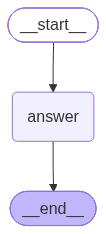

{'question': 'What is the capital of France? One word.', 'answer': 'Paris.'}

In [4]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# 1) STATE: what the graph remembers while it runs.
class State(TypedDict):
    question: str
    answer: str

# 2) NODE: a plain function. It receives the state and returns ONLY the keys it changes.
def answer_node(state: State):
    reply = llm.invoke(state["question"])
    return {"answer": reply.content}

# 3) GRAPH: register nodes, wire edges, compile.
builder = StateGraph(State)
builder.add_node("answer", answer_node)
builder.add_edge(START, "answer")
builder.add_edge("answer", END)
graph = builder.compile()

from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke({"question": "What is the capital of France? One word."})

### Step 3 · Reducers — *merging* instead of *overwriting*

By default a node's return value **overwrites** the key. Wrap a type in `Annotated[..., reducer]`
to change that. `operator.add` on a list means "append". This is how parallel nodes safely write to
the same key (used heavily in map-reduce).

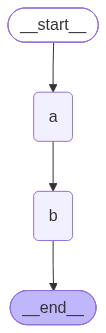

In [7]:
import operator
from typing import Annotated

class LogState(TypedDict):
    logs: Annotated[list[str], operator.add]   # reducer = append
    last: str                                  # no reducer = overwrite

def step_a(state: LogState):
    return {"logs": ["A ran"], "last": "A"}

def step_b(state: LogState):
    return {"logs": ["B ran"], "last": "B"}

b = StateGraph(LogState)
b.add_node("a", step_a); b.add_node("b", step_b)
b.add_edge(START, "a"); b.add_edge("a", "b"); b.add_edge("b", END)

graph = b.compile()
graph.invoke({"logs": [], "last": ""})
# -> logs has BOTH entries (appended); last is "B" (overwritten)

from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(graph.get_graph().draw_mermaid_png()))

### Step 4 · See the graph

`draw_mermaid()` returns text you can paste into <https://mermaid.live> (no internet needed to print it).

In [6]:
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	answer(answer)
	__end__([<p>__end__</p>]):::last
	__start__ --> answer;
	answer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



### Where to go next
| Notebook | Pattern |
|---|---|
| 01–04 | Planning · Reflection · Map-Reduce · Multi-agent |
| 05–08 | Human-in-the-loop: Approval · Wait-for-input · Time-travel · Review tool calls |
| 09–14 | Extra patterns: Tool use (ReAct) · Prompt chaining · Routing · Parallelization · Memory · Guardrails |